# PCA vs t-SNE — Dimensionality Reduction

Practice activity from Microsoft *Foundations of AI and Machine Learning* — Module: AI/ML Algorithms and Techniques.

Reduce a 3-feature customer dataset (`AnnualIncome`, `SpendingScore`, `Age`) down to 2 dimensions using two complementary techniques:
- **PCA** — linear projection along axes of maximum variance.
- **t-SNE** — non-linear embedding that preserves local neighborhoods.

## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

## 3. Load the dataset

Same 44 customers as the K-means/DBSCAN activities, now with a third feature, `Age`. Age increases moderately with income through the normal customers — that gives PCA a real correlation to exploit.

In [2]:
annual_income = [
    15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5,
    20, 20.5, 21, 21.5, 22, 22.5, 23, 23.5, 24, 24.5,
    25, 25.5, 26, 26.5, 27, 27.5, 28, 28.5, 29, 29.5,
    30, 30.5, 31, 31.5, 32, 32.5, 33, 33.5, 34, 34.5,
    35,
    80, 85, 90,  # outliers
]

spending_score = [
    39, 42, 45, 48, 51, 54, 57, 60, 63, 66,
    68, 70, 72, 73, 75, 76, 78, 79, 80, 82,
    83, 84, 85, 86, 87, 87, 88, 88, 89, 89,
    90, 91, 92, 93, 94, 95, 95, 96, 97, 98,
    99,
    40, 60, 80,
]

age = [
    22, 25, 23, 28, 30, 26, 24, 29, 27, 31,
    33, 29, 32, 35, 34, 28, 30, 27, 32, 36,
    38, 42, 40, 45, 47, 44, 49, 46, 50, 48,
    52, 55, 53, 51, 56, 54, 58, 57, 59, 60,
    62,
    55, 60, 65,
]

df = pd.DataFrame({
    'AnnualIncome':  annual_income,
    'SpendingScore': spending_score,
    'Age':           age,
})
df.head()

,AnnualIncome,SpendingScore,Age
0,15.0,39,22
1,15.5,42,25
2,16.0,45,23
3,16.5,48,28
4,17.0,51,30


### Correlations

Pairwise correlation gives a hint about how compressible the data is. If features are strongly correlated, PCA will compress aggressively.

In [3]:
df.corr().round(3)

,AnnualIncome,SpendingScore,Age
AnnualIncome,1.000,0.090,0.682
SpendingScore,0.090,1.000,0.678
Age,0.682,0.678,1.000


## 4. Preprocess — scale features

PCA chases variance and t-SNE uses pairwise distances; without scaling, a feature with a larger range would dominate both.

In [4]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled, columns=['AnnualIncome', 'SpendingScore', 'Age'])
df_scaled.head()

,AnnualIncome,SpendingScore,Age
0,-0.869761,-2.175423,-1.527331
1,-0.838899,-2.001178,-1.292631
2,-0.808036,-1.826933,-1.449098
3,-0.777174,-1.652688,-1.057930
4,-0.746311,-1.478443,-0.901463


In [5]:
# Color outliers red in every reduced-space plot below
is_outlier = np.array([False] * 41 + [True] * 3)
colors = np.where(is_outlier, 'red', 'steelblue')

## 5. PCA — 3D ➜ 2D

In [6]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(scaled)
df_pca = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Cumulative variance:      {pca.explained_variance_ratio_.cumsum()}')
df_pca.head()

Explained variance ratio: [0.66923995 0.30324964]
Cumulative variance:      [0.66923995 0.97248958]


,PCA1,PCA2
0,-2.610357,-0.929625
1,-2.343612,-0.827893
2,-2.346903,-0.725910
3,-1.972144,-0.624279
4,-1.759406,-0.522497


### PCA loadings — what each principal component is made of

In [7]:
pd.DataFrame(pca.components_, columns=df.columns, index=['PC1', 'PC2']).round(3)

,AnnualIncome,SpendingScore,Age
PC1,0.513,0.51,0.690
PC2,-0.705,0.71,-0.001


## 6. Visualize PCA

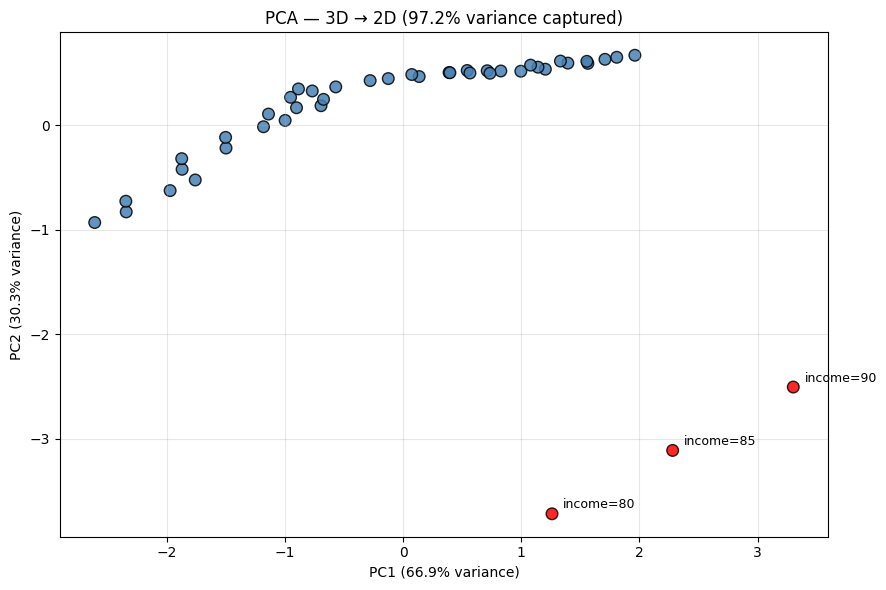

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_pca['PCA1'], df_pca['PCA2'], c=colors, s=70, edgecolor='k', alpha=0.85)
for i, is_o in enumerate(is_outlier):
    if is_o:
        ax.annotate(f"income={df.iloc[i]['AnnualIncome']:.0f}",
                    (df_pca.iloc[i]['PCA1'], df_pca.iloc[i]['PCA2']),
                    xytext=(8, 4), textcoords='offset points', fontsize=9)
ax.set_title(f'PCA — 3D → 2D '
             f'({pca.explained_variance_ratio_.sum()*100:.1f}% variance captured)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. t-SNE — 3D ➜ 2D

`perplexity=3` matches the activity. Small perplexity emphasizes very local neighborhoods, which is appropriate for a 44-row dataset (general rule: 5–50, and never larger than `n-1`).

We also pass `init='pca'` for a stable, deterministic starting point — without it the layout shifts between runs.

In [9]:
tsne = TSNE(n_components=2, perplexity=3, random_state=42, init='pca')
df_tsne = tsne.fit_transform(scaled)
df_tsne = pd.DataFrame(df_tsne, columns=['t-SNE1', 't-SNE2'])
df_tsne.head()

,t-SNE1,t-SNE2
0,-87.502922,-10.028689
1,-83.873215,-4.615057
2,-80.122360,-8.949994
3,-69.589493,2.319927
4,-65.202309,5.575859


## 8. Visualize t-SNE

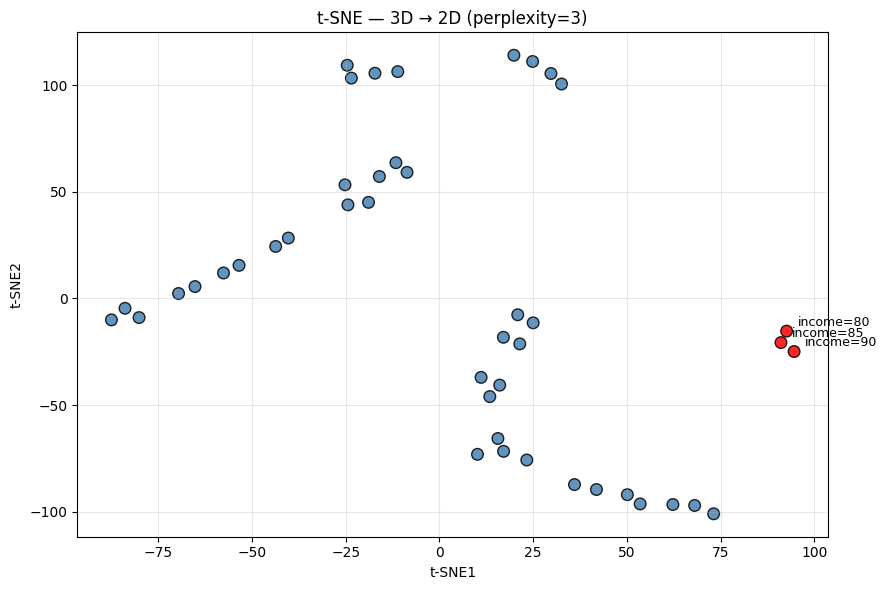

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_tsne['t-SNE1'], df_tsne['t-SNE2'], c=colors, s=70, edgecolor='k', alpha=0.85)
for i, is_o in enumerate(is_outlier):
    if is_o:
        ax.annotate(f"income={df.iloc[i]['AnnualIncome']:.0f}",
                    (df_tsne.iloc[i]['t-SNE1'], df_tsne.iloc[i]['t-SNE2']),
                    xytext=(8, 4), textcoords='offset points', fontsize=9)
ax.set_title('t-SNE — 3D → 2D (perplexity=3)')
ax.set_xlabel('t-SNE1')
ax.set_ylabel('t-SNE2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Side-by-side

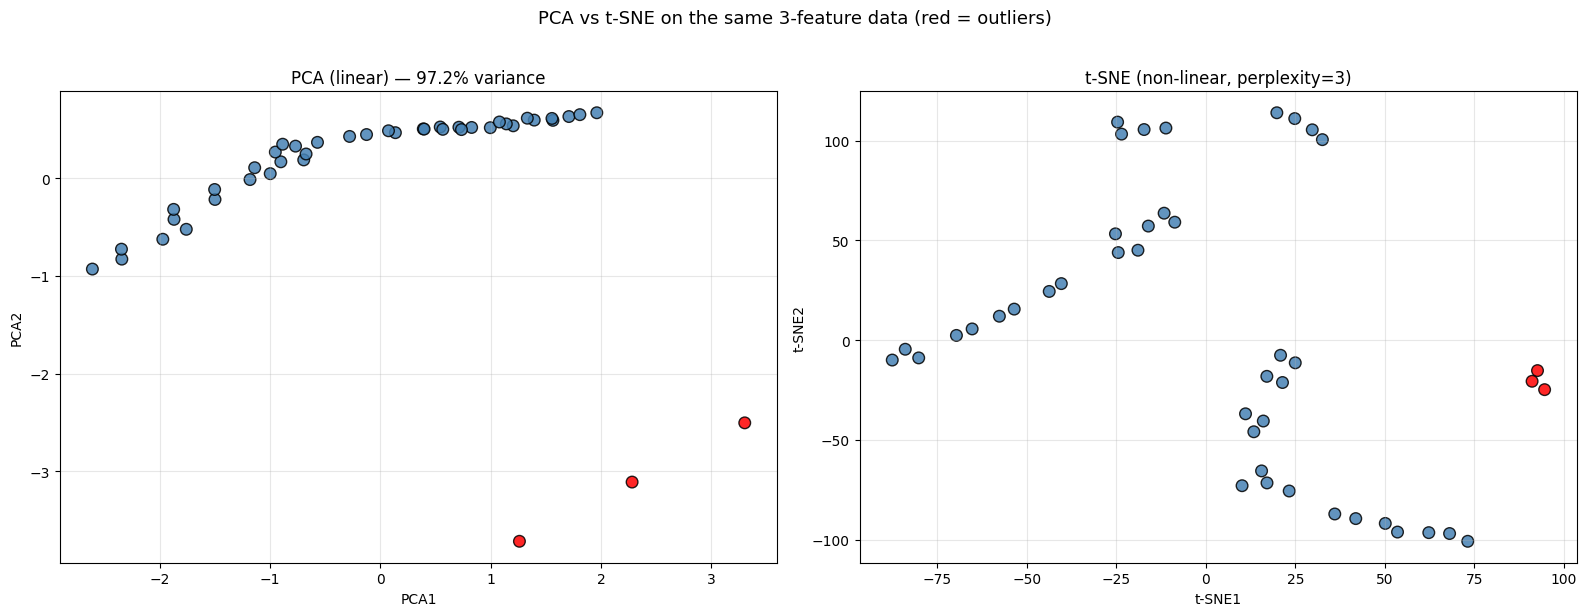

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(df_pca['PCA1'], df_pca['PCA2'], c=colors, s=70, edgecolor='k', alpha=0.85)
axes[0].set_title(f'PCA (linear) — {pca.explained_variance_ratio_.sum()*100:.1f}% variance')
axes[0].set_xlabel('PCA1')
axes[0].set_ylabel('PCA2')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_tsne['t-SNE1'], df_tsne['t-SNE2'], c=colors, s=70, edgecolor='k', alpha=0.85)
axes[1].set_title('t-SNE (non-linear, perplexity=3)')
axes[1].set_xlabel('t-SNE1')
axes[1].set_ylabel('t-SNE2')
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA vs t-SNE on the same 3-feature data (red = outliers)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Key takeaways

| | **PCA** | **t-SNE** |
|---|---|---|
| Type | Linear projection | Non-linear embedding |
| What it preserves | Global variance | Local neighborhoods |
| Deterministic? | Yes | No (random init unless you pin it) |
| Interpretable axes? | Yes — loadings show feature contributions | No — distances and cluster sizes are not meaningful |
| Inverse transform? | Yes | No |
| Good for | Compression, feature engineering, first-pass viz | Exploratory cluster visualization |

**On this dataset:**
- PCA captures **~97% of the variance in 2 components**. PC1 is essentially "overall customer scale" (all three loadings positive); PC2 contrasts Income vs Spending while ignoring Age (loadings ≈ −0.71, +0.71, 0). The 3 outliers shoot far out along PC1 — exactly because they have unusual values on the dominant axis.
- t-SNE produces a curved path through the normal customers (preserving the local order along the diagonal band) with the outliers separated. The *shape* of that path on the t-SNE plot is not meaningful — t-SNE distances aren't comparable to PCA distances.

**Practical advice:**
- Start with PCA. If 2 components capture >90% of variance, that's usually enough for tabular data.
- Reach for t-SNE (or UMAP — faster, more stable) when you specifically want to *see* clusters in high-dimensional data like image embeddings or word vectors.
- Never read *distance* off a t-SNE plot the way you would a PCA plot.